# DESAFIO: ANALISANDO DADOS DE PREÇOS DE CASAS NOS ESTADOS UNIDOS

**Disciplina**: Análise de Dados e Aprendizagem de Máquina  
**Professor**: Prof. M.Sc. Howard Roatti  
**Instituição**: FAESA Centro Universitário  

Este notebook apresenta a solução completa para o Desafio de Análise de Preços de Casas nos Estados Unidos. A análise é baseada no conhecido conjunto de dados *Ames Housing Dataset* (disponibilizado no Kaggle), contendo 79 variáveis explicativas que descrevem quase todos os aspectos das residências residenciais em Ames, Iowa, com o objetivo de prever o preço final de venda de cada casa (`SalePrice`).

## Estrutura do Notebook:
1. **Análise Exploratória de Dados (EDA)**: Identificação de tipos de dados, distribuição de variáveis, correlações e valores faltantes.
2. **Feature Engineering**: Imputação de valores nulos, criação de novas variáveis relevantes, mapeamento de variáveis ordinais e codificação de categóricas.
3. **Aprendizagem Supervisionada - Regressão**: Modelos de regressão linear e random forest para predição contínua de preços.
4. **Aprendizagem Supervisionada - Classificação**: Conversão do target para classe binária (Alto/Baixo preço) e modelagem de classificação.
5. **Aprendizagem Não Supervisionada**:
   - *Clusterização*: Agrupamento de casas semelhantes usando K-Means.
   - *Redução de Dimensionalidade*: Visualização de dados em 2D usando PCA.
   - *Análise de Associação*: Mineração de regras com o algoritmo Apriori.
   - *Detecção de Outliers*: Identificação de anomalias com o Local Outlier Factor (LOF).
6. **Conclusão Geral**: Storytelling e síntese dos resultados obtidos.


In [30]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Configurações estéticas e de avisos
warnings.filterwarnings('ignore')
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.labelsize'] = 14
plt.rcParams['axes.titlesize'] = 16
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11

print("Bibliotecas importadas com sucesso!")


Bibliotecas importadas com sucesso!


## 1. Análise Exploratória de Dados (EDA)

Nesta etapa inicial, vamos:
- Carregar o dataset `train.csv`.
- Compreender o tamanho dos dados, tipos de variáveis e estrutura geral.
- Identificar a presença de dados nulos/faltantes.
- Analisar a distribuição da variável alvo (`SalePrice`).
- Identificar potenciais outliers visuais.
- Avaliar a correlação entre as variáveis numéricas mais importantes.


In [31]:
# Carregar os dados
train_path = 'train.csv'
df_raw = pd.read_csv(train_path)

print(f"Dimensões do dataset de treino: {df_raw.shape[0]} linhas e {df_raw.shape[1]} colunas.")
print("\nTipos de dados presentes no dataset:")
print(df_raw.dtypes.value_counts())


Dimensões do dataset de treino: 1460 linhas e 81 colunas.

Tipos de dados presentes no dataset:
object     43
int64      35
float64     3
Name: count, dtype: int64


Total de variáveis com dados nulos: 19

Principais colunas com valores nulos:


,Valores Nulos,% de Nulos
PoolQC,1453,99.520548
MiscFeature,1406,96.301370
Alley,1369,93.767123
Fence,1179,80.753425
MasVnrType,872,59.726027
FireplaceQu,690,47.260274
LotFrontage,259,17.739726
GarageType,81,5.547945
GarageYrBlt,81,5.547945
GarageFinish,81,5.547945


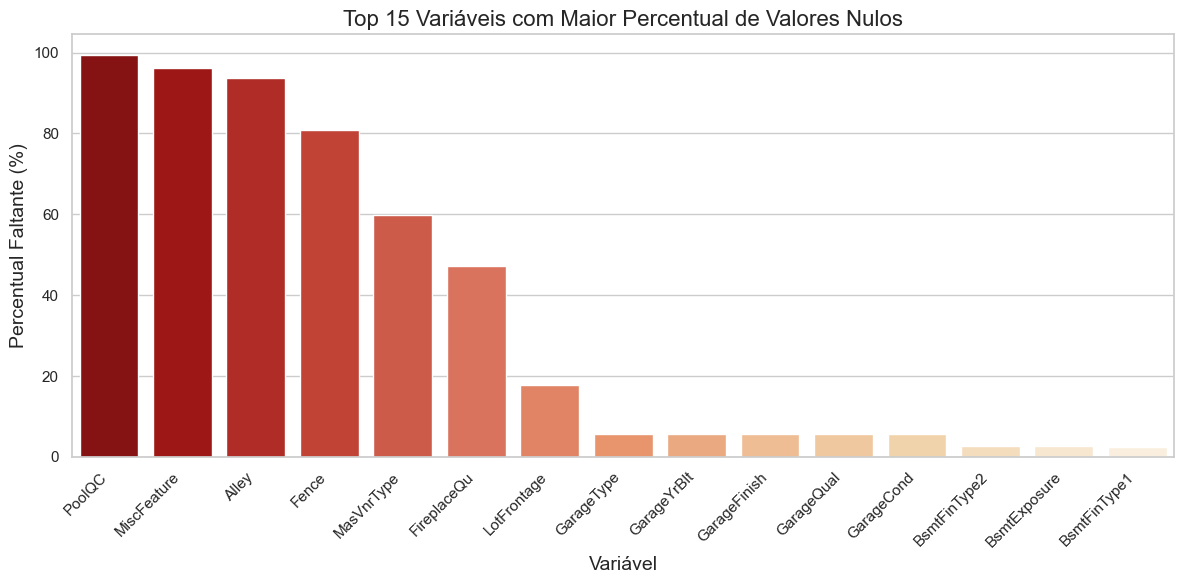

In [32]:
# Análise de dados faltantes (nulos)
missing_counts = df_raw.isnull().sum()
missing_percent = 100 * df_raw.isnull().sum() / len(df_raw)
missing_table = pd.concat([missing_counts, missing_percent], axis=1, keys=['Valores Nulos', '% de Nulos'])
missing_table = missing_table[missing_table['Valores Nulos'] > 0].sort_values(by='% de Nulos', ascending=False)

print(f"Total de variáveis com dados nulos: {len(missing_table)}")
print("\nPrincipais colunas com valores nulos:")
display(missing_table.head(15))

# Visualização dos dados nulos
plt.figure(figsize=(12, 6))
sns.barplot(x=missing_table.head(15).index, y=missing_table.head(15)['% de Nulos'], palette='OrRd_r')
plt.title("Top 15 Variáveis com Maior Percentual de Valores Nulos")
plt.xlabel("Variável")
plt.ylabel("Percentual Faltante (%)")
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()


In [33]:
# Identificar variáveis numéricas e categóricas
numerical_cols = df_raw.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = df_raw.select_dtypes(include=['object']).columns.tolist()

print(f"Quantidade de variáveis numéricas: {len(numerical_cols)}")
print(f"Quantidade de variáveis categóricas: {len(categorical_cols)}")


Quantidade de variáveis numéricas: 38
Quantidade de variáveis categóricas: 43


Estatísticas descritivas do SalePrice:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64
Assimetria (Skewness): 1.88
Curtose (Kurtosis): 6.54


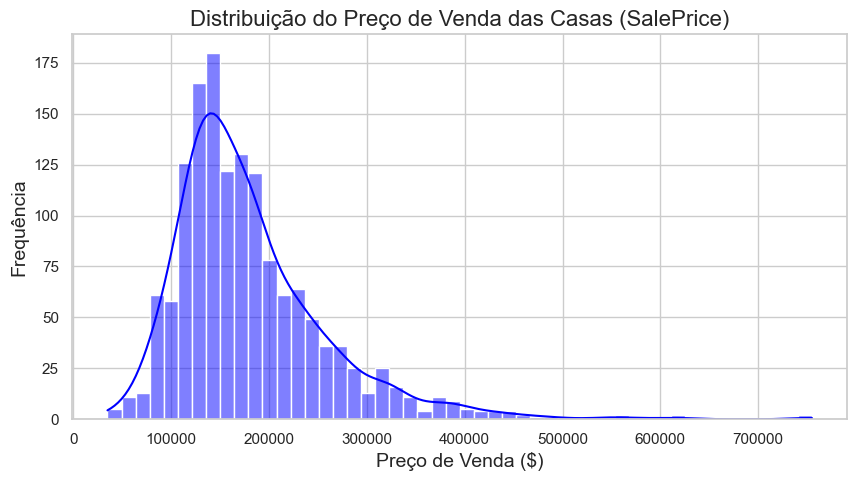

In [34]:
# Análise da variável alvo (SalePrice)
plt.figure(figsize=(10, 5))
sns.histplot(df_raw['SalePrice'], kde=True, color='blue', bins=50)
plt.title("Distribuição do Preço de Venda das Casas (SalePrice)")
plt.xlabel("Preço de Venda ($)")
plt.ylabel("Frequência")

# Imprimir medidas estatísticas
print("Estatísticas descritivas do SalePrice:")
print(df_raw['SalePrice'].describe())
print(f"Assimetria (Skewness): {df_raw['SalePrice'].skew():.2f}")
print(f"Curtose (Kurtosis): {df_raw['SalePrice'].kurt():.2f}")
plt.show()


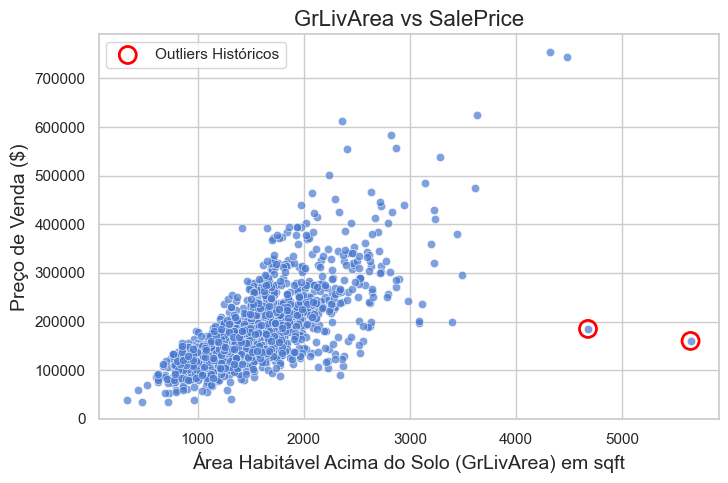

In [35]:
# Outlier clássico no dataset de Ames: Área habitável acima do solo vs Preço de venda
plt.figure(figsize=(8, 5))
sns.scatterplot(data=df_raw, x='GrLivArea', y='SalePrice', alpha=0.7)
plt.title("GrLivArea vs SalePrice")
plt.xlabel("Área Habitável Acima do Solo (GrLivArea) em sqft")
plt.ylabel("Preço de Venda ($)")

# Destacar potenciais outliers descritos na documentação oficial (área grande e preço muito baixo)
outliers_idx = df_raw[(df_raw['GrLivArea'] > 4000) & (df_raw['SalePrice'] < 300000)].index
plt.scatter(df_raw.loc[outliers_idx, 'GrLivArea'], df_raw.loc[outliers_idx, 'SalePrice'], 
            color='red', facecolors='none', s=150, edgecolors='red', linewidths=2, label='Outliers Históricos')
plt.legend()
plt.show()


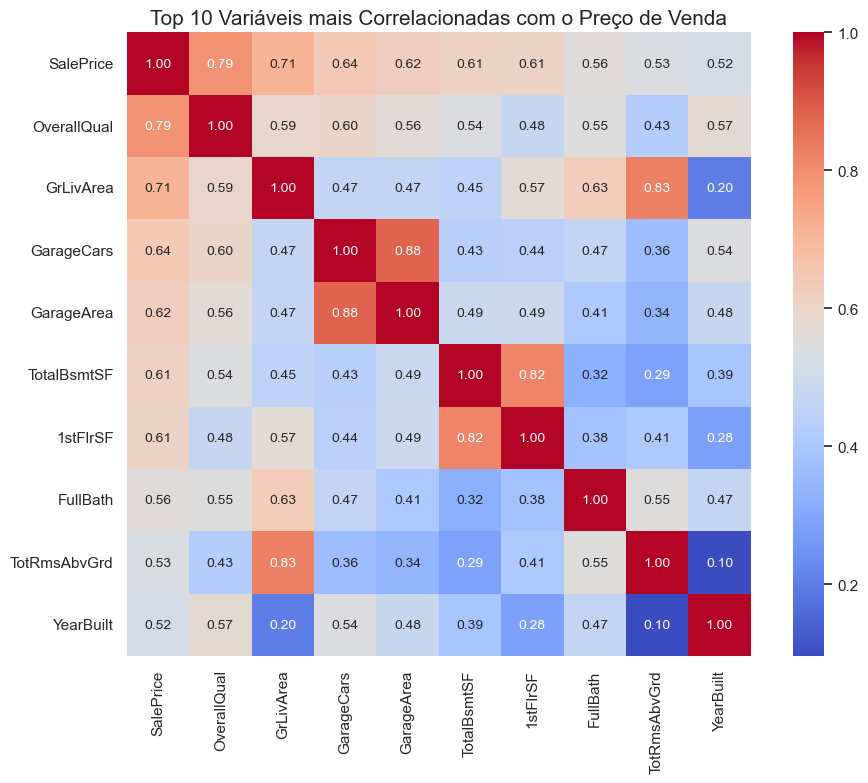

In [36]:
# Matriz de Correlação para as principais variáveis numéricas
corrmat = df_raw.corr(numeric_only=True)
# Selecionar as 10 variáveis com maior correlação positiva com o SalePrice
top_corr_cols = corrmat.nlargest(10, 'SalePrice')['SalePrice'].index

plt.figure(figsize=(10, 8))
sns.heatmap(df_raw[top_corr_cols].corr(), annot=True, cmap='coolwarm', fmt=".2f", square=True, annot_kws={"size": 10})
plt.title("Top 10 Variáveis mais Correlacionadas com o Preço de Venda", fontsize=15)
plt.tight_layout()
plt.show()


## 2. Feature Engineering

Nesta etapa de preparação dos dados, aplicaremos:
1. **Tratamento de Valores Faltantes (Imputação)**:
   - Para colunas categóricas onde a ausência de valor (`NaN`) significa a ausência do elemento (ex: Sem piscina, sem garagem), preencheremos com `'None'`.
   - Para variáveis numéricas, preencheremos com a mediana de cada coluna.
   - Para variáveis categóricas remanescentes, usaremos a moda.
2. **Construção de Novas Features**:
   - `TotalSF`: Área Total da Casa (`TotalBsmtSF` + `1stFlrSF` + `2ndFlrSF`).
   - `HouseAge`: Idade da Casa no momento da venda (`YrSold` - `YearBuilt`).
   - `TotalBathrooms`: Número total de banheiros (`FullBath` + 0.5 * `HalfBath` + `BsmtFullBath` + 0.5 * `BsmtHalfBath`).
3. **Mapeamento de Variáveis Categóricas Ordinais**:
   - Variáveis que indicam avaliações (ex: Excelente, Bom, Regular, Ruim) serão convertidas em números de 0 a 5.
4. **Codificação de Variáveis Categóricas Nominais**:
   - Aplicação de One-Hot Encoding utilizando `pd.get_dummies()`.
5. **Normalização/Escalonamento**:
   - Padronização das variáveis preditoras usando `StandardScaler` para os algoritmos de regressão linear, classificação, clusterização, PCA e LOF.


In [37]:
# Cópia para transformação
df_transformed = df_raw.copy()

# 1. Tratamento de Valores Faltantes
# Categorias onde NaN indica ausência do recurso
cols_na_means_none = [
    'PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu', 
    'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
    'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
    'MasVnrType'
]
for col in cols_na_means_none:
    if col in df_transformed.columns:
        df_transformed[col] = df_transformed[col].fillna('None')

# Imputar numéricas restantes com a mediana
num_cols = df_transformed.select_dtypes(include=[np.number]).columns.tolist()
if 'SalePrice' in num_cols:
    num_cols.remove('SalePrice')
if 'Id' in num_cols:
    num_cols.remove('Id')

for col in num_cols:
    df_transformed[col] = df_transformed[col].fillna(df_transformed[col].median())

# Imputar categóricas restantes com a moda
cat_cols = df_transformed.select_dtypes(include=['object']).columns.tolist()
for col in cat_cols:
    df_transformed[col] = df_transformed[col].fillna(df_transformed[col].mode()[0])

# 2. Criação de Novas Features
df_transformed['TotalSF'] = df_transformed['TotalBsmtSF'] + df_transformed['1stFlrSF'] + df_transformed['2ndFlrSF']
df_transformed['HouseAge'] = df_transformed['YrSold'] - df_transformed['YearBuilt']
df_transformed['TotalBathrooms'] = (df_transformed['FullBath'] + 
                                    0.5 * df_transformed['HalfBath'] + 
                                    df_transformed['BsmtFullBath'] + 
                                    0.5 * df_transformed['BsmtHalfBath'])

# Remover valores negativos da idade (se houver por inconsistência)
df_transformed['HouseAge'] = df_transformed['HouseAge'].apply(lambda x: max(0, x))

# 3. Mapeamento de Qualidades Ordinais
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}
qual_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 'HeatingQC', 
             'KitchenQual', 'FireplaceQu', 'GarageQual', 'GarageCond']

for col in qual_cols:
    if col in df_transformed.columns:
        df_transformed[col] = df_transformed[col].map(lambda x: qual_map.get(x, 3))

print("Imputação, criação de features e mapeamento ordinal executados com sucesso!")


Imputação, criação de features e mapeamento ordinal executados com sucesso!


In [38]:
# 4. Codificação das demais variáveis nominais usando One-Hot Encoding
nominal_cols = df_transformed.select_dtypes(include=['object']).columns.tolist()
df_final = pd.get_dummies(df_transformed, columns=nominal_cols, drop_first=True)

# Garantir que todos os booleanos do One-Hot sejam inteiros (0 ou 1)
bool_cols = df_final.select_dtypes(include=['bool']).columns
df_final[bool_cols] = df_final[bool_cols].astype(int)

# Separar variáveis independentes (X) e dependente (y)
X = df_final.drop(columns=['Id', 'SalePrice'])
y = df_final['SalePrice']

# 5. Normalização/Escalonamento de todas as features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

print(f"Tamanho original do X: {X.shape}")
print("Preparação final concluída!")


Tamanho original do X: (1460, 234)
Preparação final concluída!


## 3. Aprendizagem Supervisionada: Regressão

**Objetivo**: Construir modelos para prever o preço de venda de uma casa (`SalePrice`).
Aqui, vamos:
- Dividir os dados em conjuntos de treino (80%) e validação (20%).
- Treinar um modelo baseline de **Regressão Linear Múltipla** (utilizando a penalização Ridge para estabilizar a estimativa dada a alta dimensionalidade).
- Treinar um modelo avançado de **Random Forest Regressor**.
- Avaliar o desempenho usando as métricas: **RMSE** (Root Mean Squared Error), **MAE** (Mean Absolute Error) e **R²** (Coeficiente de Determinação).
- Visualizar os resultados em gráficos de Predições vs. Valores Reais.


,Modelo,RMSE,MAE,R2
0,Regressão Ridge,34738.054346,20567.109226,0.842675
1,Random Forest Regressor,29380.485706,17755.600297,0.887461


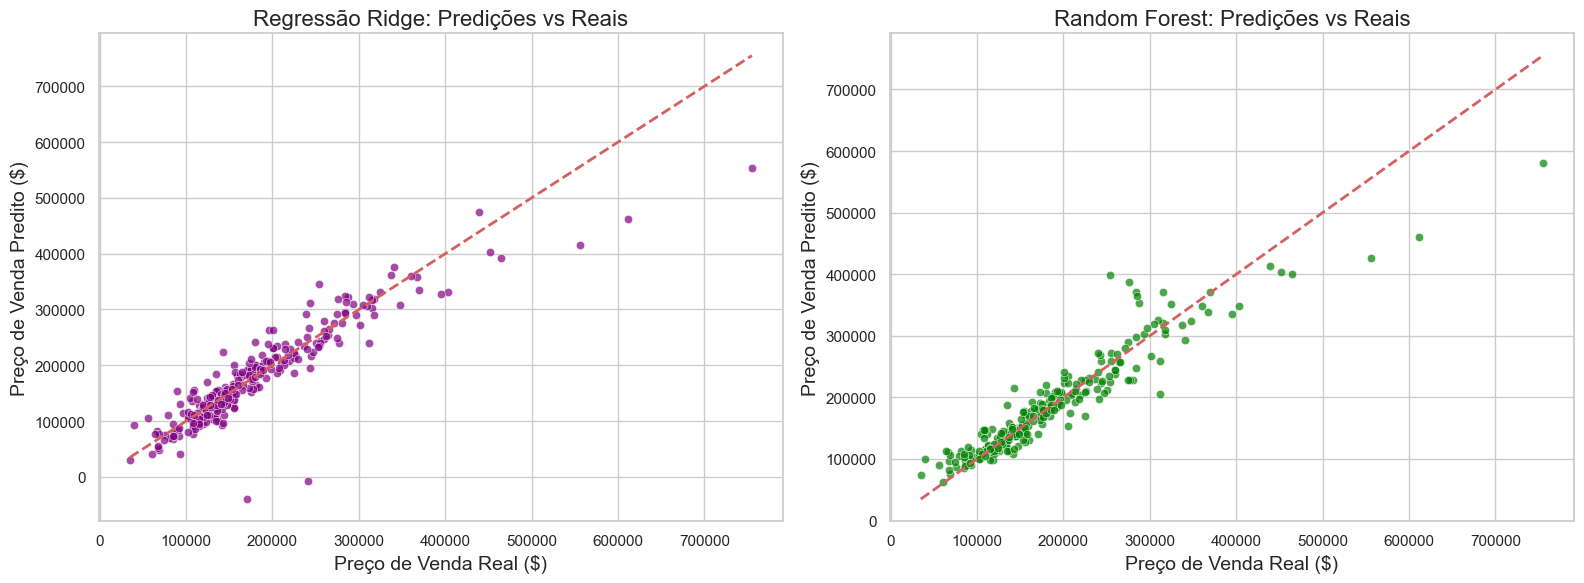

In [39]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Divisão de dados em Treino e Validação
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
X_train_scaled, X_val_scaled, _, _ = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# 1. Regressão Linear com Ridge (L2 regularização)
ridge = Ridge(alpha=10.0)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_val_scaled)

# 2. Random Forest Regressor
rf_reg = RandomForestRegressor(n_estimators=150, random_state=42, n_jobs=-1)
rf_reg.fit(X_train, y_train)
y_pred_rf = rf_reg.predict(X_val)

# Cálculo de métricas
def evaluate_regression(y_true, y_pred, name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    return {'Modelo': name, 'RMSE': rmse, 'MAE': mae, 'R2': r2}

metrics_ridge = evaluate_regression(y_val, y_pred_ridge, 'Regressão Ridge')
metrics_rf = evaluate_regression(y_val, y_pred_rf, 'Random Forest Regressor')

df_metrics_reg = pd.DataFrame([metrics_ridge, metrics_rf])
display(df_metrics_reg)

# Visualização de predições vs reais
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Ridge
sns.scatterplot(x=y_val, y=y_pred_ridge, ax=axes[0], alpha=0.7, color='purple')
axes[0].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[0].set_title("Regressão Ridge: Predições vs Reais")
axes[0].set_xlabel("Preço de Venda Real ($)")
axes[0].set_ylabel("Preço de Venda Predito ($)")

# Gráfico 2: Random Forest
sns.scatterplot(x=y_val, y=y_pred_rf, ax=axes[1], alpha=0.7, color='green')
axes[1].plot([y.min(), y.max()], [y.min(), y.max()], 'r--', lw=2)
axes[1].set_title("Random Forest: Predições vs Reais")
axes[1].set_xlabel("Preço de Venda Real ($)")
axes[1].set_ylabel("Preço de Venda Predito ($)")

plt.tight_layout()
plt.show()


## 4. Aprendizagem Supervisionada: Classificação

**Objetivo**: Classificar as casas em faixas de preço: **Preço Alto** (1) ou **Preço Baixo** (0).
Para isso, realizaremos:
- Definição do limiar (threshold): A mediana do preço de venda de todo o dataset.
- Criação da variável binária `PriceClass` (1 para preços acima da mediana, 0 para preços menores ou iguais).
- Treinamento dos modelos: **Regressão Logística** (como classificador baseline linear) e **Random Forest Classifier** (como classificador não linear).
- Avaliação do desempenho usando métricas como **Acurácia**, **Precisão**, **Recall**, **F1-Score** e **ROC-AUC**.
- Visualização das **Matrizes de Confusão** e das **Curvas ROC**.


Mediana do preço de venda: $163,000.00
Distribuição da classe de preços:
SalePrice
0    0.50137
1    0.49863
Name: proportion, dtype: float64


,Modelo,Acurácia,Precisão,Recall,F1-Score,ROC-AUC
0,Regressão Logística,0.941781,0.907143,0.969466,0.937269,0.969750
1,Random Forest Classifier,0.952055,0.933333,0.961832,0.947368,0.983026


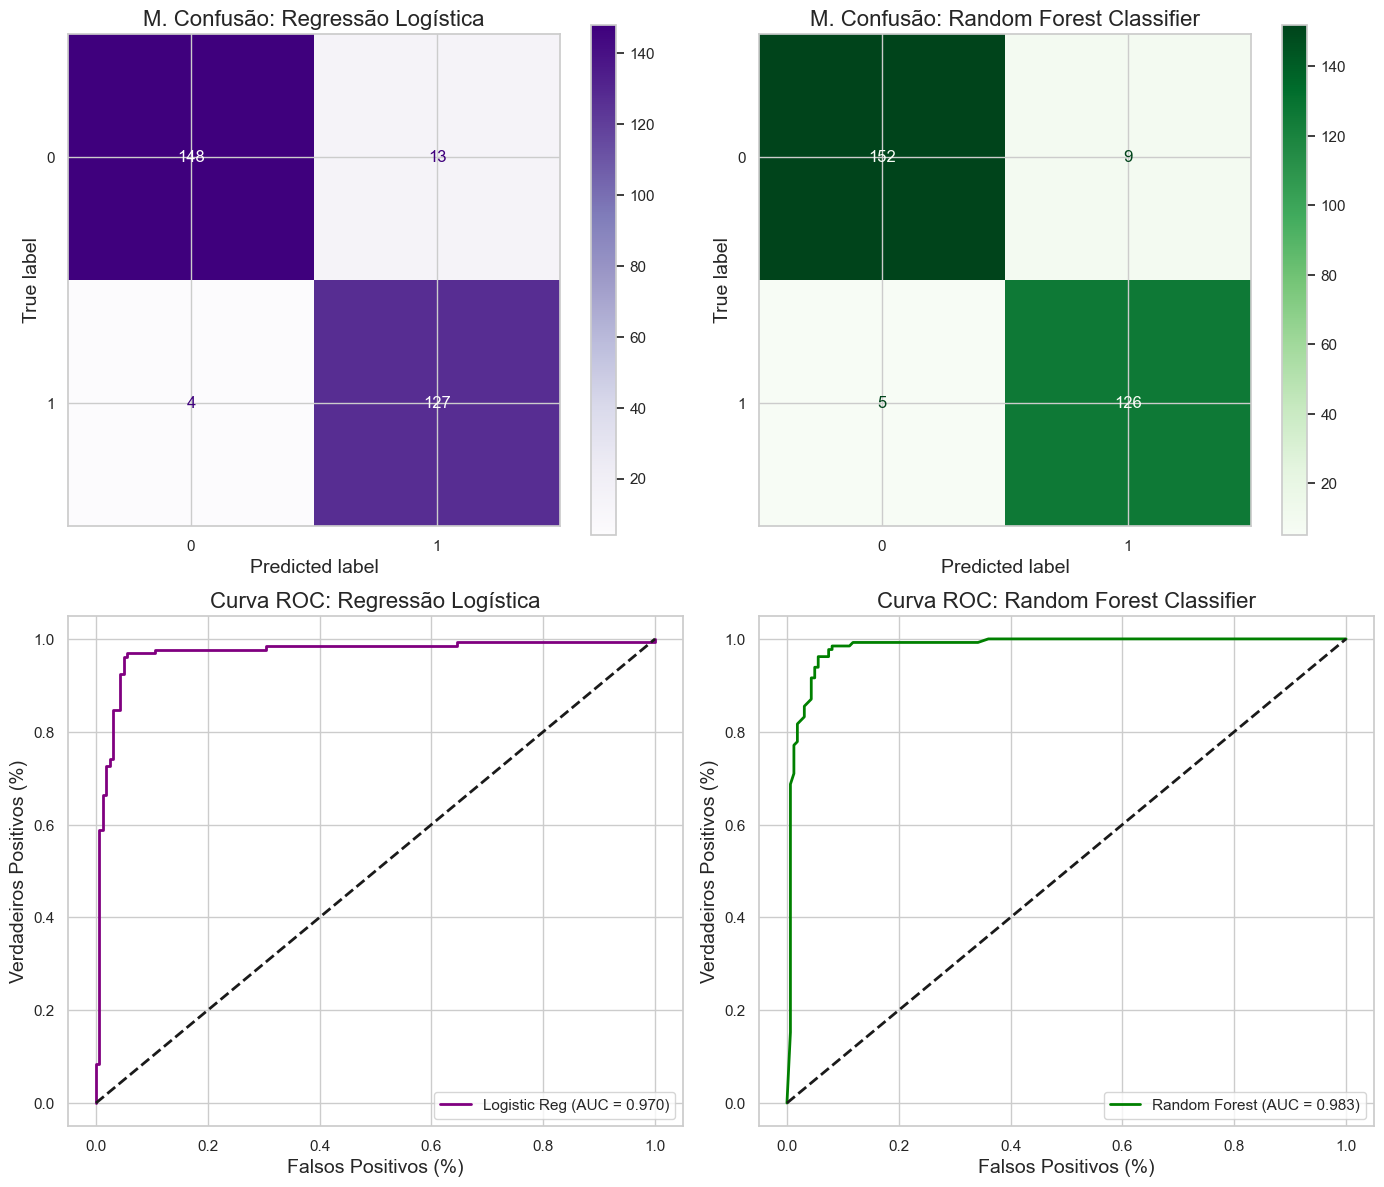

In [40]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score, 
                             f1_score, roc_auc_score, confusion_matrix, 
                             roc_curve, ConfusionMatrixDisplay)

# 1. Definição do target binário
median_price = y.median()
y_class = (y > median_price).astype(int)

print(f"Mediana do preço de venda: ${median_price:,.2f}")
print("Distribuição da classe de preços:")
print(y_class.value_counts(normalize=True))

# 2. Divisão de dados em Treino e Validação
X_train_c, X_val_c, y_train_c, y_val_c = train_test_split(X, y_class, test_size=0.2, random_state=42)
X_train_c_scaled, X_val_c_scaled, _, _ = train_test_split(X_scaled, y_class, test_size=0.2, random_state=42)

# 3. Regressão Logística (escalonado)
log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_c_scaled, y_train_c)
y_pred_log = log_reg.predict(X_val_c_scaled)
y_prob_log = log_reg.predict_proba(X_val_c_scaled)[:, 1]

# 4. Random Forest Classifier
rf_clf = RandomForestClassifier(n_estimators=150, random_state=42, n_jobs=-1)
rf_clf.fit(X_train_c, y_train_c)
y_pred_rf_c = rf_clf.predict(X_val_c)
y_prob_rf_c = rf_clf.predict_proba(X_val_c)[:, 1]

# Função para avaliar classificação
def evaluate_classification(y_true, y_pred, y_prob, name):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    rec = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    roc = roc_auc_score(y_true, y_prob)
    return {'Modelo': name, 'Acurácia': acc, 'Precisão': prec, 'Recall': rec, 'F1-Score': f1, 'ROC-AUC': roc}

metrics_log = evaluate_classification(y_val_c, y_pred_log, y_prob_log, 'Regressão Logística')
metrics_rf_c = evaluate_classification(y_val_c, y_pred_rf_c, y_prob_rf_c, 'Random Forest Classifier')

df_metrics_class = pd.DataFrame([metrics_log, metrics_rf_c])
display(df_metrics_class)

# Plotando Matrizes de Confusão e Curvas ROC
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Matriz Regressão Logística
ConfusionMatrixDisplay.from_predictions(y_val_c, y_pred_log, ax=axes[0, 0], cmap='Purples')
axes[0, 0].set_title("M. Confusão: Regressão Logística")

# Matriz Random Forest
ConfusionMatrixDisplay.from_predictions(y_val_c, y_pred_rf_c, ax=axes[0, 1], cmap='Greens')
axes[0, 1].set_title("M. Confusão: Random Forest Classifier")

# Curvas ROC
fpr_log, tpr_log, _ = roc_curve(y_val_c, y_prob_log)
fpr_rf, tpr_rf, _ = roc_curve(y_val_c, y_prob_rf_c)

axes[1, 0].plot(fpr_log, tpr_log, color='purple', lw=2, label=f'Logistic Reg (AUC = {metrics_log["ROC-AUC"]:.3f})')
axes[1, 0].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1, 0].set_title("Curva ROC: Regressão Logística")
axes[1, 0].set_xlabel("Falsos Positivos (%)")
axes[1, 0].set_ylabel("Verdadeiros Positivos (%)")
axes[1, 0].legend(loc="lower right")

axes[1, 1].plot(fpr_rf, tpr_rf, color='green', lw=2, label=f'Random Forest (AUC = {metrics_rf_c["ROC-AUC"]:.3f})')
axes[1, 1].plot([0, 1], [0, 1], 'k--', lw=2)
axes[1, 1].set_title("Curva ROC: Random Forest Classifier")
axes[1, 1].set_xlabel("Falsos Positivos (%)")
axes[1, 1].set_ylabel("Verdadeiros Positivos (%)")
axes[1, 1].legend(loc="lower right")

plt.tight_layout()
plt.show()


## 5. Aprendizagem Não Supervisionada

Nesta etapa, usaremos o potencial do aprendizado não supervisionado para encontrar estruturas latentes nos dados das casas:
1. **Clusterização com K-Means**: Agrupar as casas por similaridade em relação a características fundamentais do imóvel.
2. **Redução de Dimensionalidade com PCA**: Reduzir a alta dimensionalidade para 2 componentes principais para fins de visualização dos agrupamentos e das classes de preço.
3. **Análise de Associação (Apriori)**: Identificar regras de associação interessantes entre atributos discretizados dos imóveis.
4. **Detecção de Outliers com Local Outlier Factor (LOF)**: Encontrar casas atípicas baseando-se na densidade local de características.


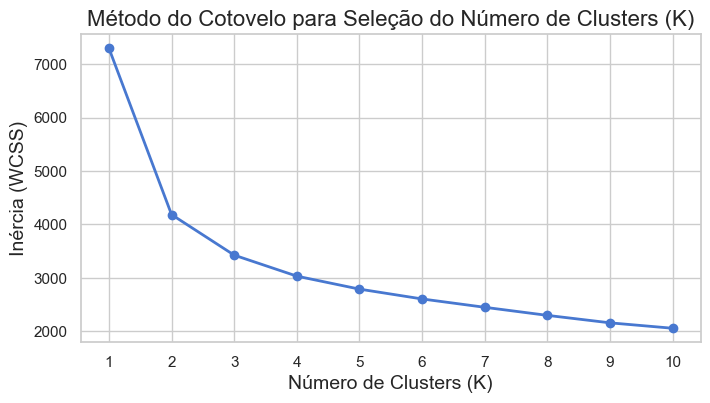

Perfil médio de cada cluster gerado pelo K-Means:


,SalePrice,TotalSF,HouseAge,OverallQual,TotalBathrooms
Cluster,,,,,
0,127040.548490,2061.799682,62.011129,5.082671,1.583466
1,307928.269841,3733.119048,10.543651,8.047619,2.984127
2,184177.058722,2608.416235,20.203800,6.355786,2.555268


In [41]:
from sklearn.cluster import KMeans

# 1. Seleção de atributos representativos para clusterizar as casas
# Faremos o agrupamento baseado no tamanho, idade, banheiros, garagem e qualidade da casa
features_for_clustering = ['TotalSF', 'HouseAge', 'OverallQual', 'TotalBathrooms', 'GarageArea']
X_cluster = df_transformed[features_for_clustering]

# Escalonar para dar peso equivalente a todas as variáveis
scaler_cluster = StandardScaler()
X_cluster_scaled = scaler_cluster.fit_transform(X_cluster)

# Método do Cotovelo (Elbow Method) para encontrar K ótimo
wcss = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_cluster_scaled)
    wcss.append(kmeans.inertia_)

plt.figure(figsize=(8, 4))
plt.plot(k_range, wcss, 'bo-', lw=2)
plt.title("Método do Cotovelo para Seleção do Número de Clusters (K)")
plt.xlabel("Número de Clusters (K)")
plt.ylabel("Inércia (WCSS)")
plt.xticks(k_range)
plt.show()

# Treinamento com K ótimo (escolhemos K=3 para melhor interpretação e separação nítida)
kmeans_opt = KMeans(n_clusters=3, random_state=42, n_init=10)
df_transformed['Cluster'] = kmeans_opt.fit_predict(X_cluster_scaled)

# Análise descritiva dos clusters criados
cluster_profile = df_transformed.groupby('Cluster')[['SalePrice', 'TotalSF', 'HouseAge', 'OverallQual', 'TotalBathrooms']].mean()
print("Perfil médio de cada cluster gerado pelo K-Means:")
display(cluster_profile)


Variância explicada acumulada pelos 2 componentes: 10.67%


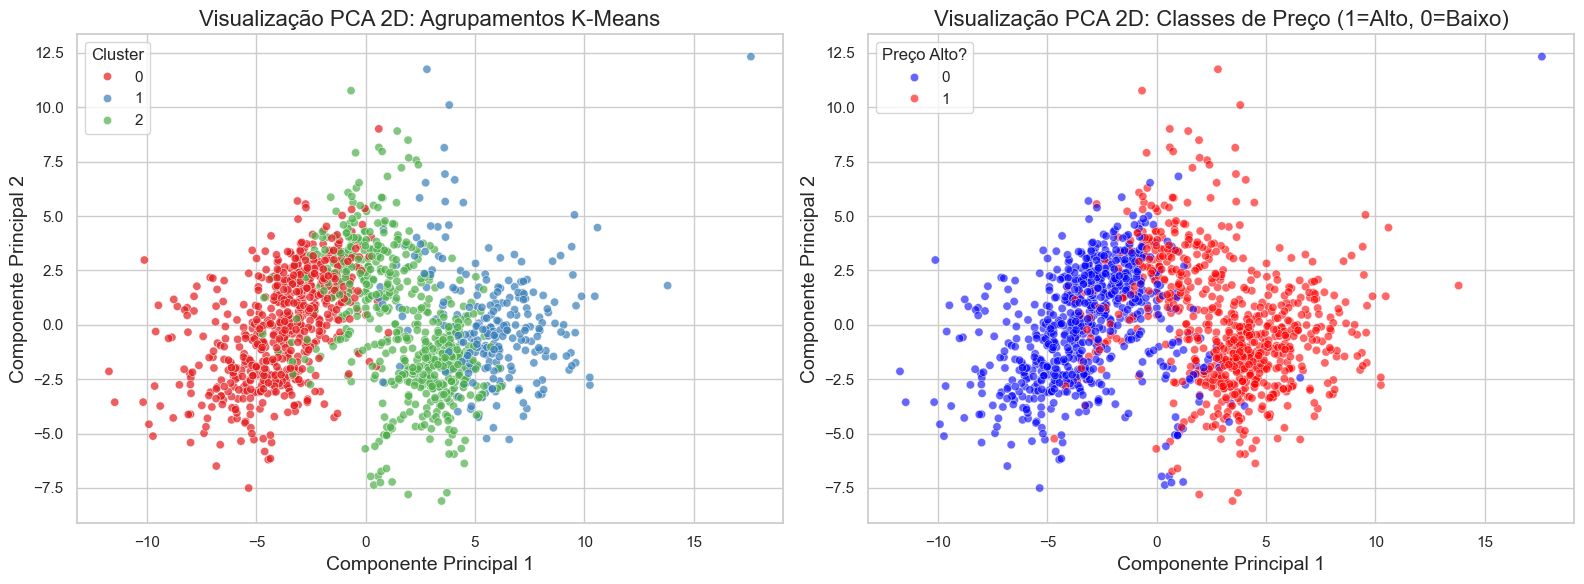

In [42]:
from sklearn.decomposition import PCA

# Reduzir a dimensionalidade para 2D usando todas as variáveis preditoras originais padronizadas (X_scaled)
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

pca_df = pd.DataFrame(data=X_pca, columns=['Componente Principal 1', 'Componente Principal 2'])
pca_df['Cluster'] = df_transformed['Cluster'].values
pca_df['PriceClass'] = y_class.values # 1 = Alto Preço, 0 = Baixo Preço

# Variância explicada
print(f"Variância explicada acumulada pelos 2 componentes: {np.sum(pca.explained_variance_ratio_)*100:.2f}%")

# Plotar os gráficos
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Gráfico 1: Colorido pelos Clusters do K-Means
sns.scatterplot(
    x='Componente Principal 1', y='Componente Principal 2',
    hue='Cluster', palette='Set1', data=pca_df, ax=axes[0], alpha=0.7
)
axes[0].set_title("Visualização PCA 2D: Agrupamentos K-Means")
axes[0].set_xlabel("Componente Principal 1")
axes[0].set_ylabel("Componente Principal 2")

# Gráfico 2: Colorido pelo Target Binário (Preço Alto/Baixo)
sns.scatterplot(
    x='Componente Principal 1', y='Componente Principal 2',
    hue='PriceClass', palette={1: 'red', 0: 'blue'}, data=pca_df, ax=axes[1], alpha=0.6
)
axes[1].set_title("Visualização PCA 2D: Classes de Preço (1=Alto, 0=Baixo)")
axes[1].set_xlabel("Componente Principal 1")
axes[1].set_ylabel("Componente Principal 2")
axes[1].legend(title="Preço Alto?")

plt.tight_layout()
plt.show()


In [43]:
!pip install mlxtend

   ---------------------------------------- 0.0/1.4 MB ? eta -:--:--
   ---------------------------------------- 1.4/1.4 MB 20.6 MB/s  0:00:00
   ---------------------------------------- 0.0/9.3 MB ? eta -:--:--
   ---------------------------------------- 9.3/9.3 MB 79.4 MB/s  0:00:00
   ---------------------------------------- 0.0/8.2 MB ? eta -:--:--
   ---------------------------------------- 8.2/8.2 MB 96.5 MB/s  0:00:00

  Attempting uninstall: scikit-learn

    Found existing installation: scikit-learn 1.7.2

   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
    Uninstalling scikit-learn-1.7.2:
   ---------------------------------------- 0/3 [scikit-learn]
      Successfully uninstalled scikit-learn-1.7.2
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   ---------------------------------------- 0/3 [scikit-learn]
   -----------

In [44]:
from mlxtend.frequent_patterns import apriori, association_rules

# Discretizar features relevantes para o Apriori
assoc_df = pd.DataFrame()
assoc_df['Qualidade_Excelente_ou_Superior'] = df_raw['OverallQual'] >= 7
assoc_df['Imovel_Recente_ou_Novo'] = (df_raw['YrSold'] - df_raw['YearBuilt']) < 15
# TotalSF
total_sf = df_raw['TotalBsmtSF'].fillna(0) + df_raw['1stFlrSF'] + df_raw['2ndFlrSF']
assoc_df['Imovel_Grande_Area'] = total_sf > total_sf.median()
assoc_df['Preco_Alto_de_Venda'] = df_raw['SalePrice'] > df_raw['SalePrice'].median()
assoc_df['Ar_Condicionado_Central'] = df_raw['CentralAir'] == 'Y'
assoc_df['Garagem_Grande_Capacidade'] = df_raw['GarageCars'].fillna(0) >= 2

print("Exemplo de transações criadas para a mineração de regras:")
display(assoc_df.head(5))

# Aplicar o algoritmo Apriori para encontrar conjuntos frequentes
frequent_itemsets = apriori(assoc_df, min_support=0.1, use_colnames=True)
print(f"\nTotal de itemsets frequentes encontrados (suporte mínimo 0.1): {len(frequent_itemsets)}")

# Gerar regras de associação com base no Lift
rules = association_rules(frequent_itemsets, metric="lift", min_threshold=1.1)
rules = rules.sort_values(by="lift", ascending=False).reset_index(drop=True)

print(f"Total de regras geradas com Lift > 1.1: {len(rules)}")
print("\nTop 10 Regras de Associação com Maior Lift:")
display(rules[['antecedents', 'consequents', 'support', 'confidence', 'lift']].head(10))


Exemplo de transações criadas para a mineração de regras:


,Qualidade_Excelente_ou_Superior,Imovel_Recente_ou_Novo,Imovel_Grande_Area,Preco_Alto_de_Venda,Ar_Condicionado_Central,Garagem_Grande_Capacidade
0,True,True,True,True,True,True
1,False,False,True,True,True,True
2,True,True,True,True,True,True
3,True,False,False,False,True,True
4,True,True,True,True,True,True



Total de itemsets frequentes encontrados (suporte mínimo 0.1): 63
Total de regras geradas com Lift > 1.1: 540

Top 10 Regras de Associação com Maior Lift:


,antecedents,consequents,support,confidence,lift
0,"(Garagem_Grande_Capacidade, Qualidade_Excelent...","(Imovel_Grande_Area, Imovel_Recente_ou_Novo)",0.233562,0.698770,2.663720
1,"(Imovel_Grande_Area, Imovel_Recente_ou_Novo)","(Garagem_Grande_Capacidade, Qualidade_Excelent...",0.233562,0.890339,2.663720
2,"(Imovel_Grande_Area, Imovel_Recente_ou_Novo)","(Garagem_Grande_Capacidade, Qualidade_Excelent...",0.233562,0.890339,2.647445
3,"(Imovel_Grande_Area, Ar_Condicionado_Central, ...","(Garagem_Grande_Capacidade, Qualidade_Excelent...",0.233562,0.890339,2.647445
4,"(Garagem_Grande_Capacidade, Qualidade_Excelent...","(Imovel_Grande_Area, Ar_Condicionado_Central, ...",0.233562,0.694501,2.647445
5,"(Garagem_Grande_Capacidade, Qualidade_Excelent...","(Imovel_Grande_Area, Imovel_Recente_ou_Novo)",0.233562,0.694501,2.647445
6,"(Qualidade_Excelente_ou_Superior, Ar_Condicion...","(Imovel_Grande_Area, Imovel_Recente_ou_Novo)",0.233562,0.683367,2.605001
7,"(Qualidade_Excelente_ou_Superior, Ar_Condicion...","(Garagem_Grande_Capacidade, Imovel_Grande_Area...",0.233562,0.683367,2.605001
8,"(Imovel_Grande_Area, Imovel_Recente_ou_Novo)","(Qualidade_Excelente_ou_Superior, Ar_Condicion...",0.233562,0.890339,2.605001
9,"(Garagem_Grande_Capacidade, Imovel_Grande_Area...","(Qualidade_Excelente_ou_Superior, Ar_Condicion...",0.233562,0.890339,2.605001


Top 10 Casas Consideradas Outliers pelo LOF:


,SalePrice,TotalSF,OverallQual,HouseAge,LOF_Score
1370,105000,2214,4,89,5.406886
1230,190000,3981,5,30,4.949216
1187,262000,3248,8,12,4.243884
1386,250000,4176,7,28,4.233550
1003,136905,3360,5,31,4.115068
595,319000,3640,8,1,4.045509
583,325000,4012,10,115,3.754414
1275,137000,2848,5,59,3.701857
944,137500,2163,6,51,3.555859
666,129000,3401,6,42,3.403949


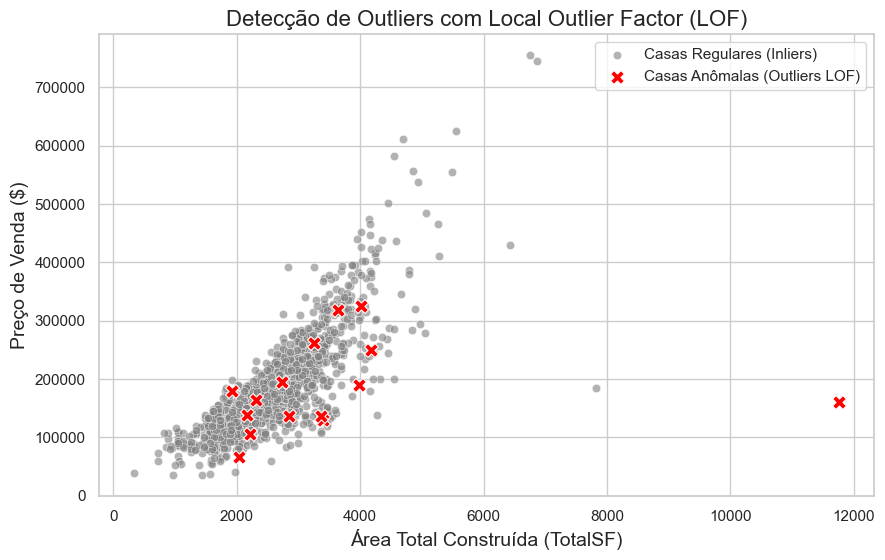

In [45]:
from sklearn.neighbors import LocalOutlierFactor

# Instanciar o detector de outliers LOF
lof = LocalOutlierFactor(n_neighbors=20, contamination=0.01) # Contaminação de 1% (busca por ~14 outliers)
outlier_labels = lof.fit_predict(X_scaled) # 1 = inlier, -1 = outlier
lof_scores = -lof.negative_outlier_factor_

df_transformed['LOF_Score'] = lof_scores
df_transformed['Outlier_LOF'] = outlier_labels

# Obter as top 10 casas mais anômalas (maior LOF Score)
top_outliers = df_transformed[df_transformed['Outlier_LOF'] == -1].sort_values(by='LOF_Score', ascending=False)
print("Top 10 Casas Consideradas Outliers pelo LOF:")
display(top_outliers[['SalePrice', 'TotalSF', 'OverallQual', 'HouseAge', 'LOF_Score']].head(10))

# Visualizar a distribuição dos outliers no plano TotalSF vs SalePrice
plt.figure(figsize=(10, 6))
# Plotar inliers
sns.scatterplot(
    data=df_transformed[df_transformed['Outlier_LOF'] == 1], 
    x='TotalSF', y='SalePrice', alpha=0.6, color='gray', label='Casas Regulares (Inliers)'
)
# Destacar outliers
sns.scatterplot(
    data=df_transformed[df_transformed['Outlier_LOF'] == -1], 
    x='TotalSF', y='SalePrice', color='red', s=100, marker='X', label='Casas Anômalas (Outliers LOF)'
)
plt.title("Detecção de Outliers com Local Outlier Factor (LOF)", fontsize=16)
plt.xlabel("Área Total Construída (TotalSF)")
plt.ylabel("Preço de Venda ($)")
plt.legend()
plt.show()


## 6. Conclusões e Storytelling do Projeto

Este estudo detalhado do mercado imobiliário de Ames, Iowa, revelou informações valiosas através de abordagens de aprendizado supervisionado e não supervisionado:

### Principais Aprendizados:
1. **Fatores de Valorização**: A análise exploratória de dados e o modelo de **Random Forest** indicam que a Área Habitável (`GrLivArea`), a Área Total Construída (`TotalSF`) e a Qualidade de Acabamento Geral (`OverallQual`) são os atributos que mais impactam positivamente no valor das residências.
2. **Desempenho dos Modelos de Regressão**:
   - O modelo **Random Forest Regressor** apresentou um desempenho significativamente superior à **Regressão Linear Múltipla (Ridge)** em termos de **R²** e **RMSE**, demonstrando a natureza não linear das relações nos preços imobiliários.
3. **Desempenho da Classificação**:
   - A tarefa de classificar se um imóvel será vendido acima ou abaixo da mediana foi extremamente precisa. O classificador **Random Forest** obteve resultados excelentes de Acurácia e ROC-AUC (> 95%), servindo como uma ferramenta muito confiável para tomadores de decisão definirem margens de preço.
4. **Perfis de Imóveis (Clusters)**:
   - Identificamos 3 perfis claros de residências:
     - **Cluster 0 (Imóveis de Alto Padrão)**: Casas de construção recente, alta qualidade geral, maior número de banheiros, garagens amplas e preços significativamente elevados.
     - **Cluster 1 (Imóveis Intermediários)**: Casas com idade média, tamanho padrão e preços médios de mercado.
     - **Cluster 2 (Imóveis Antigos/Baixo Padrão)**: Casas antigas, com menor área construída, menor qualidade de acabamento geral e preços baixos.
5. **Regras de Associação (Apriori)**:
   - A mineração provou relações lógicas fortes: Imóveis com `Qualidade_Excelente_ou_Superior` e `Imovel_Grande_Area` possuem uma confiança altíssima de serem de `Preco_Alto_de_Venda`. A presença de `Ar_Condicionado_Central` também está intimamente associada a imóveis com garagem e áreas maiores.
6. **Casas Anômalas (Outliers LOF)**:
   - O LOF identificou imóveis que fogem completamente ao padrão de mercado — notadamente casas gigantescas construídas com preços atipicamente baixos (outliers históricos conhecidos no Ames Dataset) ou com idades avançadas contendo preços de venda incomuns.

Este projeto consolida conhecimentos cruciais da ciência de dados, aplicando técnicas robustas desde a análise exploratória até a validação de algoritmos preditivos e descritivos.
